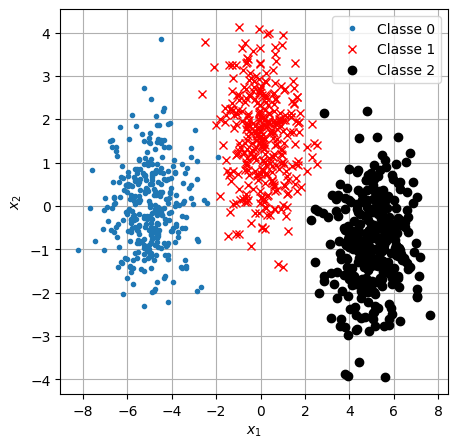

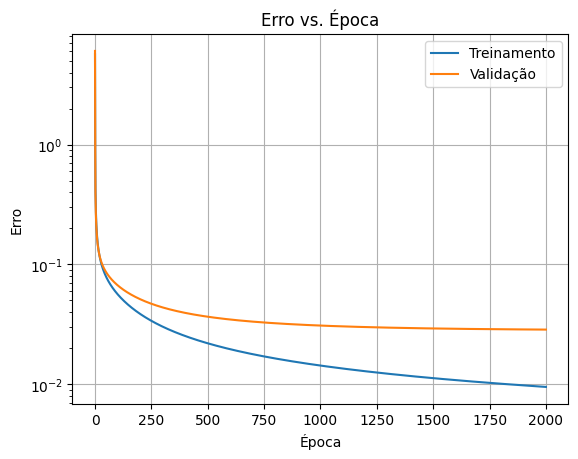

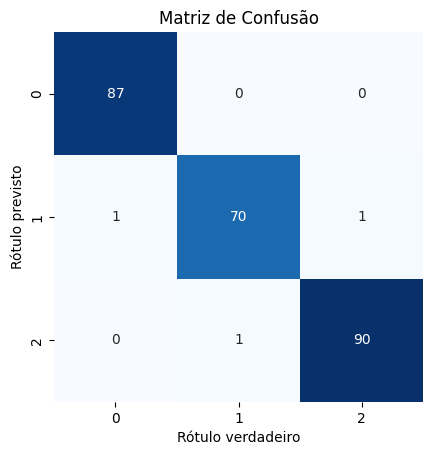

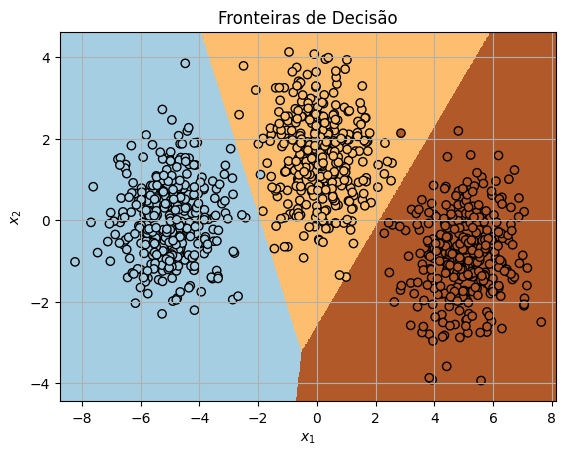

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.97      0.99      0.98        71
           2       0.99      0.99      0.99        91

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.datasets import make_blobs
import seaborn as sns

# Gerar dados de 3 classes
centers = [[-5, 0], [0, 1.5], [5, -1]]
X, y = make_blobs(n_samples=1000, centers=centers, random_state=42)

# Visualização dos dados
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)
idx2 = np.argwhere(y == 2)
fig = plt.figure(figsize=(5, 5))
plt.plot(X[idx0, 0], X[idx0, 1], '.', label='Classe 0')
plt.plot(X[idx1, 0], X[idx1, 1], 'rx', label='Classe 1')
plt.plot(X[idx2, 0], X[idx2, 1], 'ko', label='Classe 2')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid()
plt.show()

# Funções auxiliares
def to_one_hot(y):
    n_classes = y.max() + 1
    m = len(y)
    Y_one_hot = np.zeros((m, n_classes))
    Y_one_hot[np.arange(m), y] = 1
    return Y_one_hot

def from_one_hot(y):
    y_ = np.zeros((len(y), 1))
    for i in range(len(y)):
        y_[i] = np.argmax(y[i])
    return y_

def softmax(logits):
    exps = np.exp(logits)
    exp_sums = np.sum(exps, axis=1, keepdims=True)
    return exps / exp_sums

class SoftmaxRegressor():
    def __init__(self, alpha=0.1, numEpochs=1000):
        self.alpha = alpha
        self.numEpochs = numEpochs

    def hypothesis(self, X, use_a_min=False):
        g = X.dot(self.A_min if use_a_min else self.A)
        return softmax(g)

    def error_function(self, X, y, eps=1e-7):
        h = self.hypothesis(X)
        error = -np.mean(np.sum(y * np.log(h + eps), axis=1))
        return error

    def predict(self, X):
        h = self.hypothesis(X, use_a_min=True)
        return np.argmax(h, axis=1).reshape(-1, 1)

    def fit(self, X_train, y_train, X_val, y_val):
        self.A = np.random.randn(X_train.shape[1], y_train.shape[1])
        Jgd = np.zeros(self.numEpochs+1)
        Jgd_val = np.zeros(self.numEpochs+1)

        Jgd[0] = self.error_function(X_train, y_train)
        Jgd_val[0] = self.error_function(X_val, y_val)

        self.A_min = self.A
        min_val_error = float("inf")

        for epoch in range(self.numEpochs):
            grad = -1/len(y_train) * X_train.T.dot(y_train - self.hypothesis(X_train))
            self.A -= self.alpha * grad
            Jgd[epoch+1] = self.error_function(X_train, y_train)
            Jgd_val[epoch+1] = self.error_function(X_val, y_val)

            if Jgd_val[epoch+1] < min_val_error:
                min_val_error = Jgd_val[epoch+1]
                self.A_min = self.A.copy()

        return Jgd, Jgd_val

# Separar treino e teste
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.25, random_state=42)
y_train = to_one_hot(y_train_raw)
y_test = to_one_hot(y_test_raw)

# Adicionar bias (x0 = 1)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Treinar
model = SoftmaxRegressor(alpha=0.3, numEpochs=2000)
J_train, J_val = model.fit(X_train, y_train, X_test, y_test)

# Plot erro vs épocas
plt.plot(J_train, label='Treinamento')
plt.plot(J_val, label='Validação')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.title('Erro vs. Época')
plt.legend()
plt.grid()
plt.show()

# Predição e matriz de confusão
y_pred = model.predict(X_test)
mat = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=range(3), yticklabels=range(3), cmap="Blues")
plt.xlabel('Rótulo verdadeiro')
plt.ylabel('Rótulo previsto')
plt.title('Matriz de Confusão')
plt.show()

# Fronteira de decisão
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_input = np.c_[np.ones((len(xx.ravel()), 1)), xx.ravel(), yy.ravel()]
Z = model.predict(grid_input).reshape(xx.shape)

plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Fronteiras de Decisão')
plt.grid()
plt.show()

# Relatório de classificação
print(classification_report(np.argmax(y_test, axis=1), y_pred))
